# Домашнее задание: Занятие 32

**Тема: RNN для текстов**

В этом задании вы самостоятельно построите и обучите RNN для классификации текста. Каждое задание ссылается на конкретный слайд из презентации -- если забыли, вернитесь к нему.

---

## Часть 1: Теория

Отвечайте своими словами, не копируйте.

### Вопрос 1

*(Слайды 5-6)*

Почему нельзя подать текст напрямую в RNN? Опишите пайплайн обработки текста (все шаги от строки до тензора). Для каждого шага укажите, что на входе и что на выходе.

**Ваш ответ:**
Нейронные сети умеют работать только с числами, поэтому буквы не передать напрямую. Пайплайн:
1. Очистка: Удаление лишних символов. Вход: Исходная строка. Выход: Чистая строка.
2. Токенизация: Разбиение текста на отдельные части. Вход: Чистая строка. Выход: Список токенов.
3. Числовая индексация: Замена каждого уникального слова его порядковым номером из словаря. Вход: Список токенов. Выход: Список целых чисел.
4. Тензор: Преобразование списка чисел в формат данных PyTorch/TensorFlow. Вход: Список чисел. Выход: Тензор.


### Вопрос 2

*(Слайды 10-11)*

Что такое Embedding? Чем он лучше One-Hot кодирования? Если словарь содержит 8000 слов и embed_dim=128, какого размера будет Embedding таблица (матрица весов)? Сколько это параметров?

**Ваш ответ:** Embedding - это представление слова в виде вектора дробных чисел. One-Hot создает огромные векторы из нулей и одной единицы, которые не показывают связь между словами. Embedding компактнее и позволяет похожим по смыслу словам иметь похожие векторы. Таблица будет размера 8000х128. Параметров будет 1024000



### Вопрос 3

*(Слайды 12, 14)*

У нас есть модель TextRNN с параметрами: vocab_size=5000, embed_dim=64, hidden_size=128, num_classes=3. На вход подается тензор размера `(16, 50)` (batch=16, seq_len=50). Какой размер будет у тензора:
- после Embedding
- после RNN (output)
- после взятия последнего шага `out[:, -1, :]`
- на выходе модели (после Linear)

**Ваш ответ:**
- после Embedding: (16, 50, 64)
- после RNN (output): (16, 50, 128)
- после взятия последнего шага out[:, -1, :]: (16, 128)
- на выходе модели (после Linear): (16, 3)


### Вопрос 4

*(Слайды 8-9)*

Что такое PAD и UNK токены? Зачем нужен каждый из них? Что произойдет, если не делать padding и попытаться собрать батч из предложений разной длины?

**Ваш ответ:**
PAD нужен, чтобы дополнить короткие предложения до длины самого длинного в батче. Без него нельзя собрать предложения разной длины в один прямоугольный тензор и программа выдаст ошибку. UNK используется, если в тексте попалось слово, которого нет в нашем заранее собранном словаре


### Вопрос 5

*(Слайды 19-20)*

В чем разница между обычным RNN, LSTM и Bidirectional LSTM? Для каждого напишите одно преимущество. Если у нас `nn.LSTM(64, 128, bidirectional=True, batch_first=True)` и вход `(8, 40, 64)`, какой размер будет у output?

**Ваш ответ:** RNN самая простая, передает информацию по цепочке. Преимущество - работает быстро. LSTM имеет память, которая помогает не забывать начало длинных предложений. Преимущество - хорошо справляется с длинными зависимостями. Bidirectional LSTM читает текст в обе стороны слева направо и справа налево. Преимущество - лучше понимает контекст слова, видит что было до него и то, что после



---

## Часть 2: Код

### Подготовка

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [3]:
!pip install datasets -q
from google.colab import userdata
from datasets import load_dataset

hf_token = userdata.get('HF_TOKEN')

dataset = load_dataset('issai/kazsandra', 'polarity_classification', token=hf_token)
print(f'Train: {len(dataset["train"])}, Test: {len(dataset["test"])}')

polarity_classification/train_pc.csv:   0%|          | 0.00/32.6M [00:00<?, ?B/s]

valid_pc.csv: 0.00B [00:00, ?B/s]

test_pc.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/134368 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16796 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/16797 [00:00<?, ? examples/s]

Train: 134368, Test: 16797


### Задание 1: Токенизация и словарь

*(Слайды 7-8)*

Напишите функцию `tokenize`, постройте словарь из 8000 самых частых слов. Не забудьте про PAD (0) и UNK (1).

In [4]:
import re

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r'\w+', text)
    return tokens

VOCAB_SIZE = 8000
word_counts = Counter()

for row in dataset['train']:
    tokens = tokenize(row['text'])
    word_counts.update(tokens)

vocab = {'<PAD>': 0, '<UNK>': 1}
for i, (word, count) in enumerate(word_counts.most_common(VOCAB_SIZE - 2)):
    vocab[word] = i + 2

print(f'Размер словаря: {len(vocab)}')
print(f'Топ-10 слов: {word_counts.most_common(10)}')

Размер словаря: 8000
Топ-10 слов: [('өте', 36507), ('керемет', 28644), ('жақсы', 23042), ('ұнады', 18527), ('маған', 17563), ('екен', 14340), ('ойын', 12616), ('мен', 12305), ('күшті', 10143), ('рахмет', 9867)]


### Задание 2: Кодирование текста

*(Слайд 9)*

Напишите функцию `encode_text`, которая превращает строку в список индексов с padding до `max_len`. Создайте Dataset и DataLoader.

In [5]:
MAX_LEN = 80

def encode_text(text, vocab, max_len):
    tokens = tokenize(text)
    encoded = [vocab.get(token, vocab['<UNK>']) for token in tokens[:max_len]]
    padding = [vocab['<PAD>']] * (max_len - len(encoded))
    return encoded + padding

# Проверьте на примере
test_text = 'бұл қолданба өте жақсы'
encoded = encode_text(test_text, vocab, max_len=10)
print(f'Текст:       "{test_text}"')
print(f'Закодировано: {encoded}')
print(f'Длина:        {len(encoded)}')

Текст:       "бұл қолданба өте жақсы"
Закодировано: [13, 173, 2, 4, 0, 0, 0, 0, 0, 0]
Длина:        10


In [6]:
class TextDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_len):
        self.texts = hf_dataset['text']
        self.labels = hf_dataset['label']
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = encode_text(self.texts[idx], self.vocab, self.max_len)
        return torch.tensor(encoded), torch.tensor(self.labels[idx])

train_ds = TextDataset(dataset['train'], vocab, MAX_LEN)
test_ds = TextDataset(dataset['test'], vocab, MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

# Проверьте размеры
for X_batch, y_batch in train_loader:
    print(f'X_batch: {X_batch.shape}')
    print(f'y_batch: {y_batch.shape}')
    break

X_batch: torch.Size([64, 80])
y_batch: torch.Size([64])


### Задание 3: Постройте модель

*(Слайд 13)*

Напишите класс MyTextRNN с параметрами:
- embed_dim = 64
- hidden_size = 128
- num_classes = 2
- Dropout (p=0.3) между RNN и Linear

In [7]:
class MyTextRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, h_n = self.rnn(emb)
        last_step = out[:, -1, :]
        dropped = self.dropout(last_step)
        logits = self.fc(dropped)
        return logits

model = MyTextRNN(len(vocab), 64, 128, 2).to(device)
print(model)
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

MyTextRNN(
  (embedding): Embedding(8000, 64)
  (rnn): RNN(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
Параметров: 537,090


### Задание 4: Проверьте размеры

*(Слайд 14)*

Пропустите тензор `torch.randint(0, len(vocab), (4, 80))` через модель. Выведите размеры на каждом этапе: вход, после embedding, после rnn, после last step, выход.

In [8]:
x = torch.randint(0, len(vocab), (4, MAX_LEN)).to(device)
print(f'1. Вход: {x.shape}')

with torch.no_grad():
    emb = model.embedding(x)
    print(f'2. После Embedding: {emb.shape}')

    out, h_n = model.rnn(emb)
    print(f'3. После RNN (весь выход): {out.shape}')

    last_step = out[:, -1, :]
    print(f'4. Последний шаг: {last_step.shape}')

    logits = model.fc(model.dropout(last_step))
    print(f'5. Выход (logits): {logits.shape}')

1. Вход: torch.Size([4, 80])
2. После Embedding: torch.Size([4, 80, 64])
3. После RNN (весь выход): torch.Size([4, 80, 128])
4. Последний шаг: torch.Size([4, 128])
5. Выход (logits): torch.Size([4, 2])


### Задание 5: Обучите модель

*(Слайд 17)*

Напишите training loop на 10 эпох. Используйте CrossEntropyLoss и Adam с lr=0.001. Сохраняйте train_loss и test_accuracy на каждой эпохе.

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
test_accs = []

for epoch in range(10):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    test_accs.append(correct / total)
    print(f'Epoch {epoch+1}: Loss {train_losses[-1]:.4f}, Acc {test_accs[-1]:.2%}')

Epoch 1: Loss 0.4715, Acc 82.18%
Epoch 2: Loss 0.4726, Acc 82.18%
Epoch 3: Loss 0.4724, Acc 82.18%
Epoch 4: Loss 0.4718, Acc 82.18%
Epoch 5: Loss 0.4716, Acc 82.18%
Epoch 6: Loss 0.4717, Acc 82.18%
Epoch 7: Loss 0.4717, Acc 82.18%
Epoch 8: Loss 0.4717, Acc 82.18%
Epoch 9: Loss 0.4723, Acc 82.18%
Epoch 10: Loss 0.4719, Acc 82.18%


### Задание 6: Постройте графики

Постройте два графика рядом:
- Train Loss по эпохам
- Test Accuracy по эпохам

Какая финальная accuracy? Есть ли признаки переобучения?

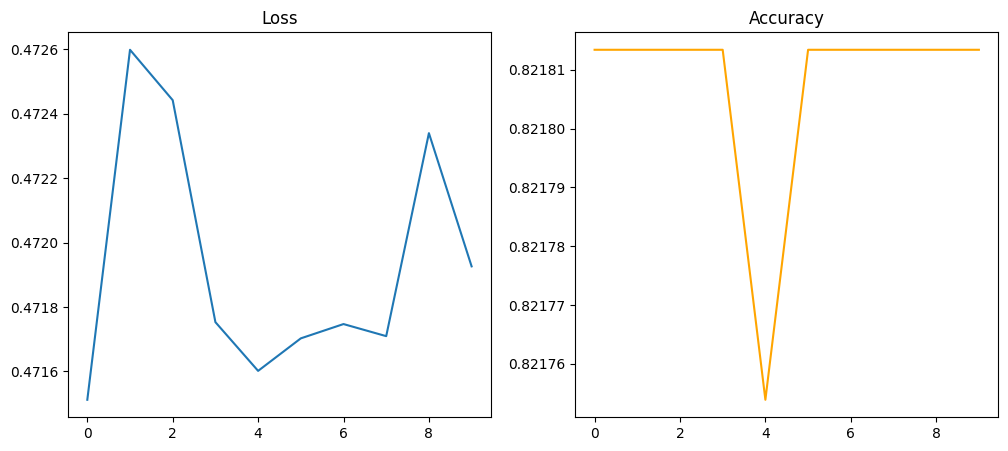

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(test_accs, label='Test Accuracy', color='orange')
plt.title('Accuracy')
plt.show()

**Ваш вывод:** Есть признаки переобучения, так как loss в моментах снижается, acccuracy тоже снижается или стоит на месте



### Задание 7: Сравнение RNN vs LSTM

*(Слайд 20)*

Создайте аналогичную модель с nn.LSTM вместо nn.RNN. Обучите на тех же данных и сравните:
- Финальную accuracy на тесте
- Графики accuracy по эпохам (обе модели на одном графике)

Какая модель лучше? Почему?

LSTM Epoch 1: Acc 82.18%
LSTM Epoch 2: Acc 82.18%
LSTM Epoch 3: Acc 82.18%
LSTM Epoch 4: Acc 82.18%
LSTM Epoch 5: Acc 82.18%
LSTM Epoch 6: Acc 82.18%
LSTM Epoch 7: Acc 84.48%
LSTM Epoch 8: Acc 87.09%
LSTM Epoch 9: Acc 87.30%
LSTM Epoch 10: Acc 87.51%


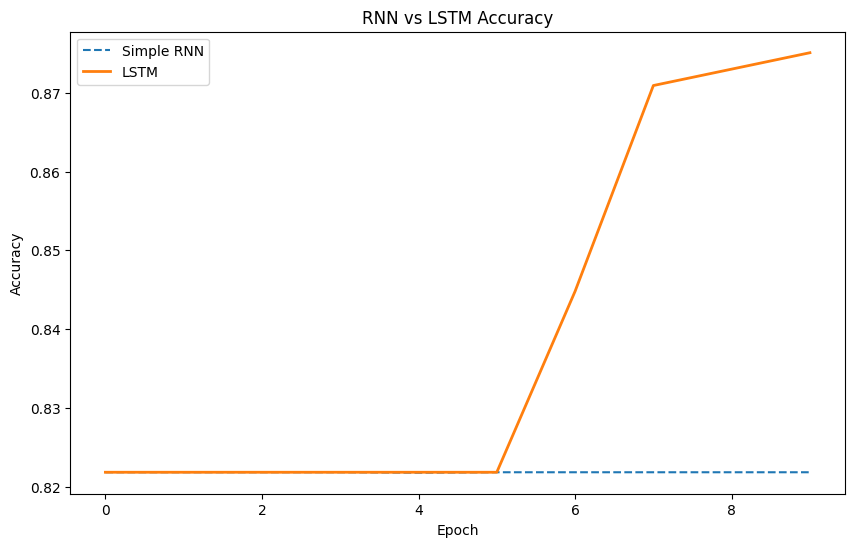

In [13]:

class MyTextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        last_step = out[:, -1, :]
        return self.fc(self.dropout(last_step))

lstm_model = MyTextLSTM(len(vocab), 64, 128, 2).to(device)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
lstm_train_losses = []
lstm_test_accs = []

for epoch in range(10):
    lstm_model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        lstm_optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        lstm_optimizer.step()
        epoch_loss += loss.item()

    lstm_train_losses.append(epoch_loss / len(train_loader))

    lstm_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = lstm_model(X_batch)
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)

    lstm_test_accs.append(correct / total)
    print(f'LSTM Epoch {epoch+1}: Acc {lstm_test_accs[-1]:.2%}')

plt.figure(figsize=(10, 6))
plt.plot(test_accs, label='Simple RNN', linestyle='--')
plt.plot(lstm_test_accs, label='LSTM', linewidth=2)
plt.title('RNN vs LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**Ваш вывод:**
LSTM лучше, так как она дольше помнит начало предложения благодаря внутреннему состоянию ячейки


---

## Часть 3: Бонус

### Бонус 1: Функция предсказания

Напишите функцию `predict_sentiment(text)`, которая принимает строку текста и возвращает предсказание модели (позитивный/негативный) и уверенность. Протестируйте на 5 своих примерах на казахском или русском.

In [ ]:
# Ваш код здесь



### Бонус 2: Эксперимент с гиперпараметрами

Попробуйте три варианта embed_dim: 32, 64, 128. Как размерность эмбеддинга влияет на accuracy? Постройте сравнительный график.

In [ ]:
# Ваш код здесь



**Ваш вывод:**

